In [475]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy import stats
from scipy.stats import t
from statsmodels.graphics.tsaplots import plot_acf

In [476]:
btc = yf.download("BTC-USD", start="2020-01-01", end="2025-01-01")
btc.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095


In [477]:
len(btc)

1827

In [478]:
btc["Return"] = btc[("Close", "BTC-USD")].pct_change()
btc = btc.dropna()
btc.head()

Price,Close,High,Low,Open,Volume,Return
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465,-0.029819
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032,0.051452
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275,0.008955
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095,0.000089
2020-01-06,7769.219238,7781.867188,7409.292969,7410.452148,23276261598,0.048291


In [479]:
btc["Return"].describe()

count    1826.000000
mean        0.001978
std         0.033546
min        -0.371695
25%        -0.012894
50%         0.000677
75%         0.016544
max         0.187465
Name: Return, dtype: float64

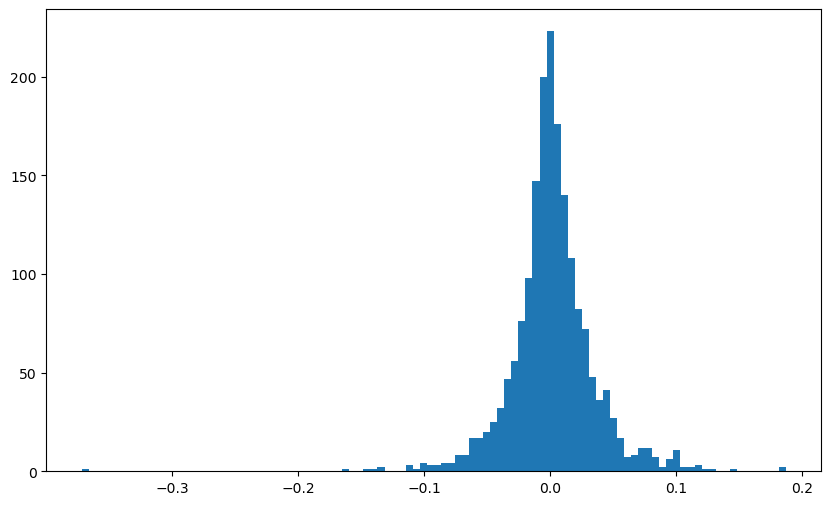

In [480]:
plt.figure(figsize=(10,6))
plt.hist(btc["Return"], bins=100)
plt.show()

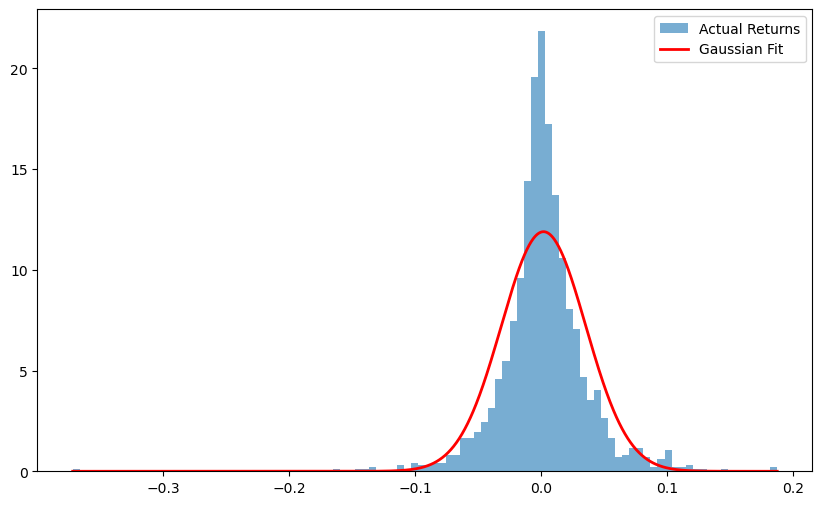

In [481]:
mu = btc["Return"].mean()
sigma = btc["Return"].std()

x = np.linspace(btc["Return"].min(),
                btc["Return"].max(),
                1000)

gaussian = norm.pdf(x, mu, sigma)

plt.figure(figsize=(10,6))
plt.hist(btc["Return"],
         bins=100,
         density=True,
         alpha=0.6,
         label="Actual Returns")

plt.plot(x,
         gaussian,
         color="red",
         linewidth=2,
         label="Gaussian Fit")

plt.legend()

plt.show()

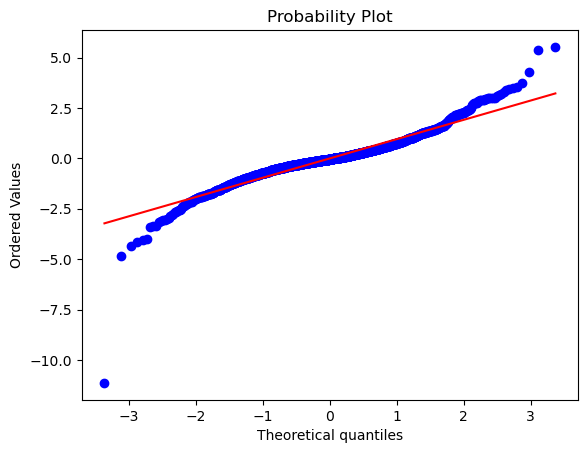

In [482]:
standardized_gaussian = (
    (btc["Return"] - mu) / sigma
)
stats.probplot(
    standardized_gaussian,
    dist="norm",
    plot=plt
)

plt.show()

In [483]:
log_likelihood_gaussian = np.sum(
    norm.logpdf(btc["Return"], mu, sigma)
)
print(log_likelihood_gaussian)

3608.508377370954


In [484]:
nu, mu_t, sigma_t = t.fit(btc["Return"])
print(nu,mu_t,sigma_t)

2.605458432115676 0.0011337183369557547 0.019715919504470526


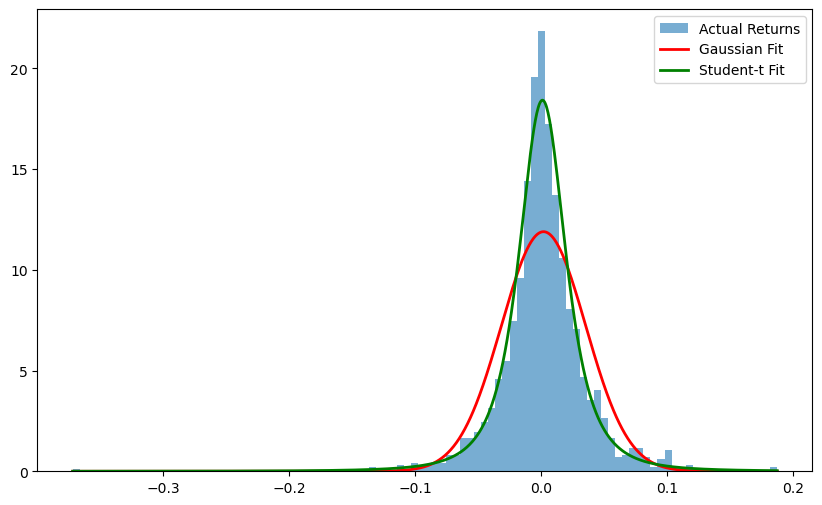

In [485]:
student_t = t.pdf(x, nu, mu_t, sigma_t)
plt.figure(figsize=(10,6))

plt.hist(btc["Return"],
         bins=100,
         density=True,
         alpha=0.6,
         label="Actual Returns")

plt.plot(x,
         gaussian,
         color="red",
         linewidth=2,
         label="Gaussian Fit")

plt.plot(x,
         student_t,
         color="green",
         linewidth=2,
         label="Student-t Fit")

plt.legend()

plt.show()

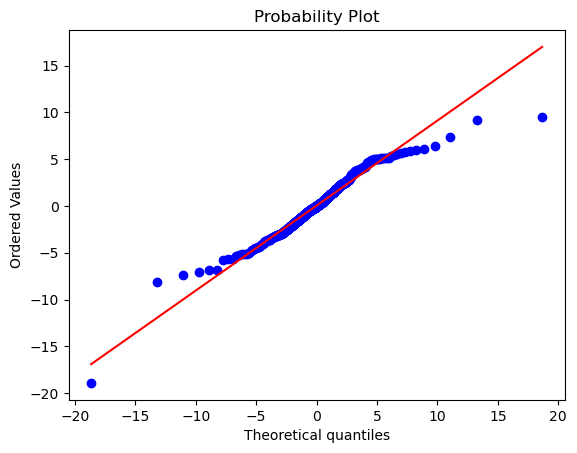

In [486]:
standardized_returns = (
    (btc["Return"] - mu_t) / sigma_t
)
stats.probplot(
    standardized_returns,
    dist=t,
    sparams=(nu,),
    plot=plt
)

plt.show()

In [487]:
log_likelihood_t = np.sum(
    t.logpdf(btc["Return"], nu, mu_t, sigma_t)
)
print(log_likelihood_t)

3828.534585487151


In [488]:
def log_posterior(nu):

    if nu <= 2:
        return -np.inf

    return np.sum(
        t.logpdf(
            btc["Return"],
            df=nu,
            loc=mu_t,
            scale=sigma_t
        )
    )

iterations = 5000
nu_current = 5
chain = []
accepted = 0


for i in range(iterations):

    nu_proposal = np.random.normal(
        nu_current,
        0.5
    )
    log_acceptance_ratio = (
        log_posterior(nu_proposal)
        -
        log_posterior(nu_current)
    )
    if np.log(np.random.rand()) < log_acceptance_ratio:
        nu_current = nu_proposal
        accepted += 1

    chain.append(nu_current)

acceptance_rate = accepted / iterations
print(acceptance_rate)

chain = np.array(chain)


0.3488


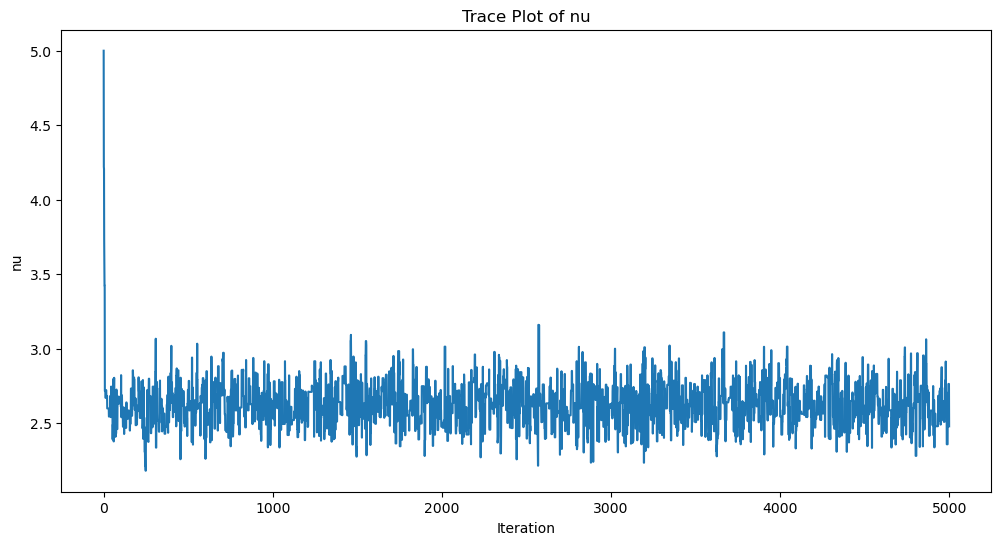

In [489]:
plt.figure(figsize=(12,6))

plt.plot(chain)

plt.xlabel("Iteration")

plt.ylabel("nu")

plt.title("Trace Plot of nu")

plt.show()

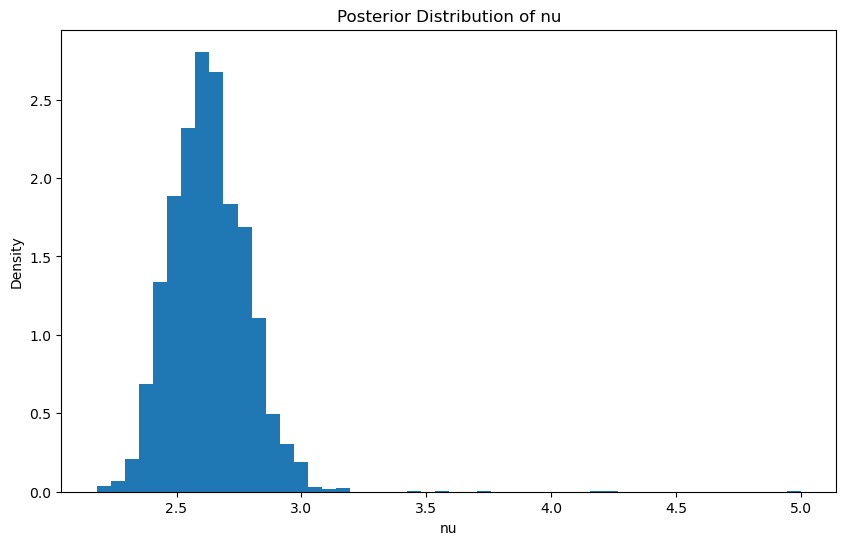

In [490]:
plt.figure(figsize=(10,6))

plt.hist(chain,
         bins=50,
         density=True)

plt.xlabel("nu")

plt.ylabel("Density")

plt.title("Posterior Distribution of nu")

plt.show()

In [491]:
burn_in = 300
chain_burned = chain[burn_in:]
nu_posterior_mean = np.mean(chain_burned)

print(nu_posterior_mean)

2.6298272668886806


<Figure size 1000x600 with 0 Axes>

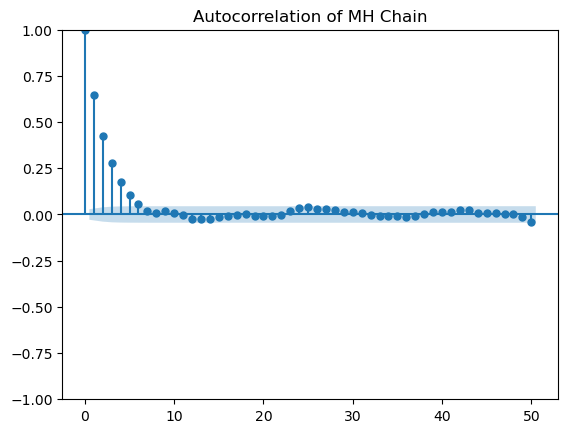

In [492]:
plt.figure(figsize=(10,6))

plot_acf(chain_burned, lags=50)

plt.title("Autocorrelation of MH Chain")

plt.show()

In [493]:
def log_posterior_full(mu, sigma, nu):

    if sigma <= 0 or nu <= 2:
        return -np.inf

    return np.sum(
        t.logpdf(
            btc["Return"],
            df=nu,
            loc=mu,
            scale=sigma
        )
    )

iterations = 10000

mu_current = mu_t
sigma_current = sigma_t
nu_current = nu

mu_chain = []
sigma_chain = []
nu_chain = []

accepted = 0

In [494]:
for i in range(iterations):

    mu_proposal = np.random.normal(
        mu_current,
        0.0003
    )

    sigma_proposal = np.random.normal(
        sigma_current,
        0.001
    )

    nu_proposal = np.random.normal(
        nu_current,
        0.3
    )

    log_acceptance_ratio = (

        log_posterior_full(
            mu_proposal,
            sigma_proposal,
            nu_proposal
        )

        -

        log_posterior_full(
            mu_current,
            sigma_current,
            nu_current
        )
    )

    if np.log(np.random.rand()) < log_acceptance_ratio:

        mu_current = mu_proposal
        sigma_current = sigma_proposal
        nu_current = nu_proposal

        accepted += 1

    mu_chain.append(mu_current)
    sigma_chain.append(sigma_current)
    nu_chain.append(nu_current)

acceptance_rate = accepted / iterations
print(acceptance_rate)

0.2991


In [495]:
burn_in = 1000
mu_chain_burned = mu_chain[burn_in:]
sigma_chain_burned = sigma_chain[burn_in:]
nu_chain_burned = nu_chain[burn_in:]

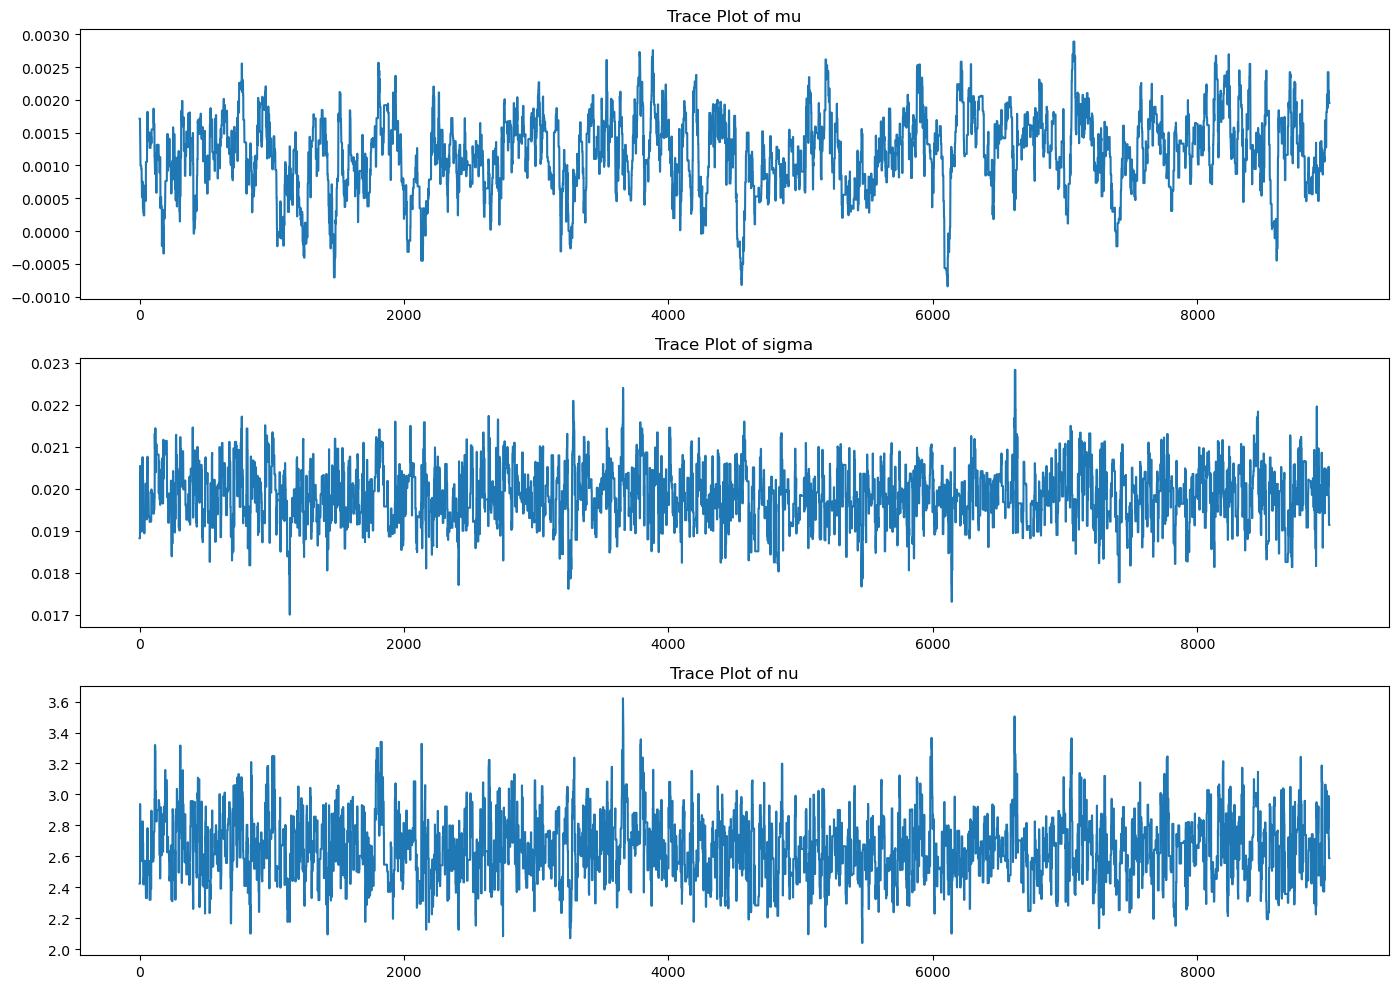

In [496]:
plt.figure(figsize=(14,10))

plt.subplot(3,1,1)
plt.plot(mu_chain_burned)
plt.title("Trace Plot of mu")

plt.subplot(3,1,2)
plt.plot(sigma_chain_burned)
plt.title("Trace Plot of sigma")

plt.subplot(3,1,3)
plt.plot(nu_chain_burned)
plt.title("Trace Plot of nu")

plt.tight_layout()

plt.show()

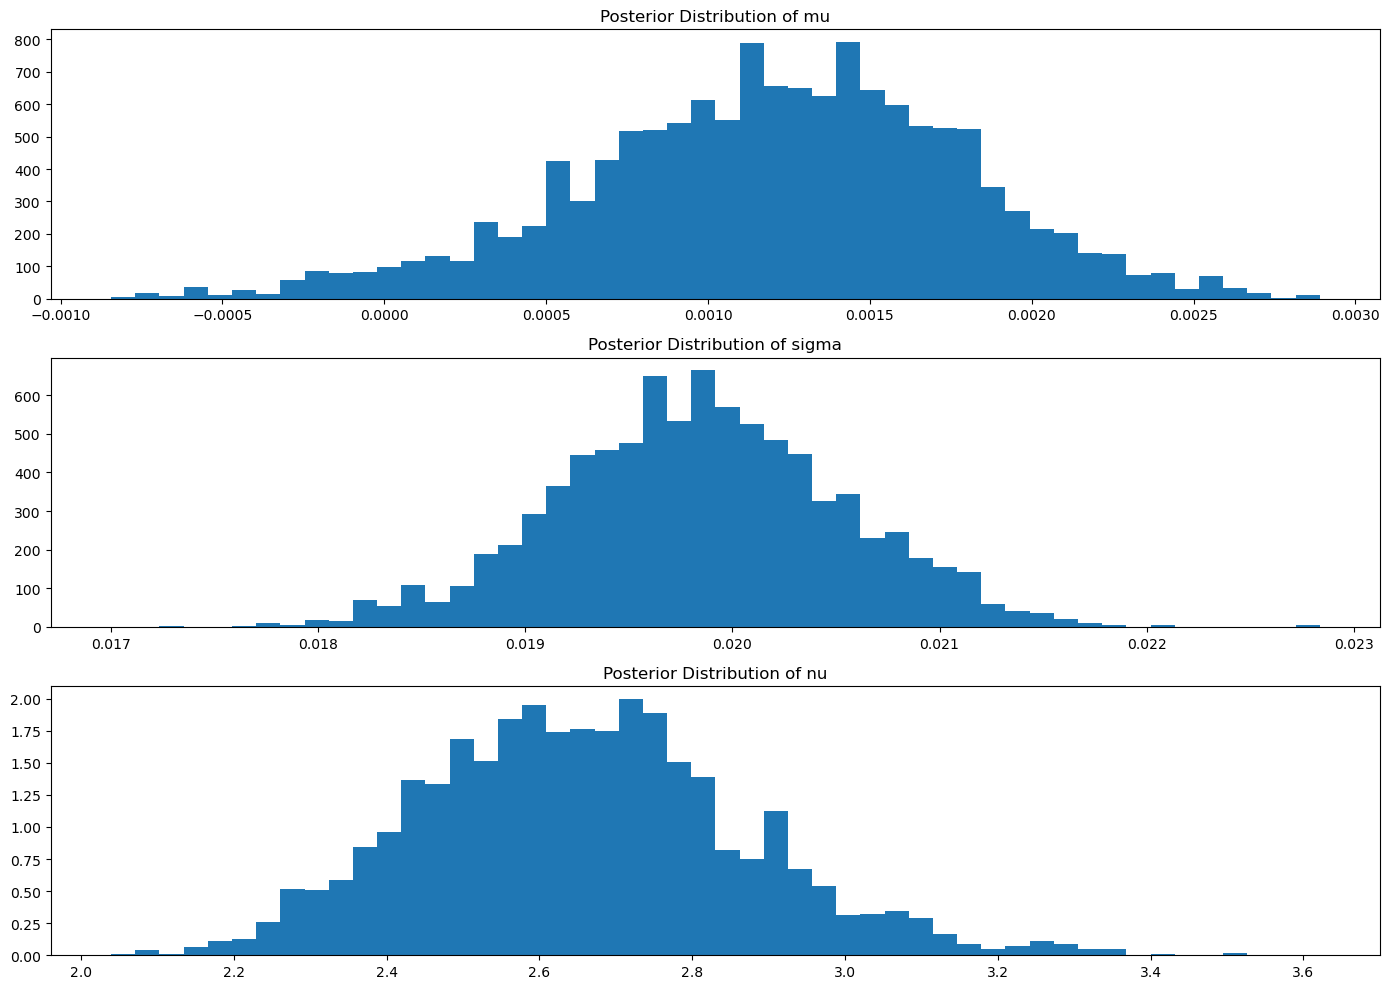

In [505]:
plt.figure(figsize=(14,10))

plt.subplot(3,1,1)
plt.hist(mu_chain_burned,
         bins=50,
         density=True)

plt.title("Posterior Distribution of mu")

plt.subplot(3,1,2)
plt.hist(sigma_chain_burned,
         bins=50,
         density=True)

plt.title("Posterior Distribution of sigma")

plt.subplot(3,1,3)
plt.hist(nu_chain_burned,
         bins=50,
         density=True)

plt.title("Posterior Distribution of nu")

plt.tight_layout()

plt.show()

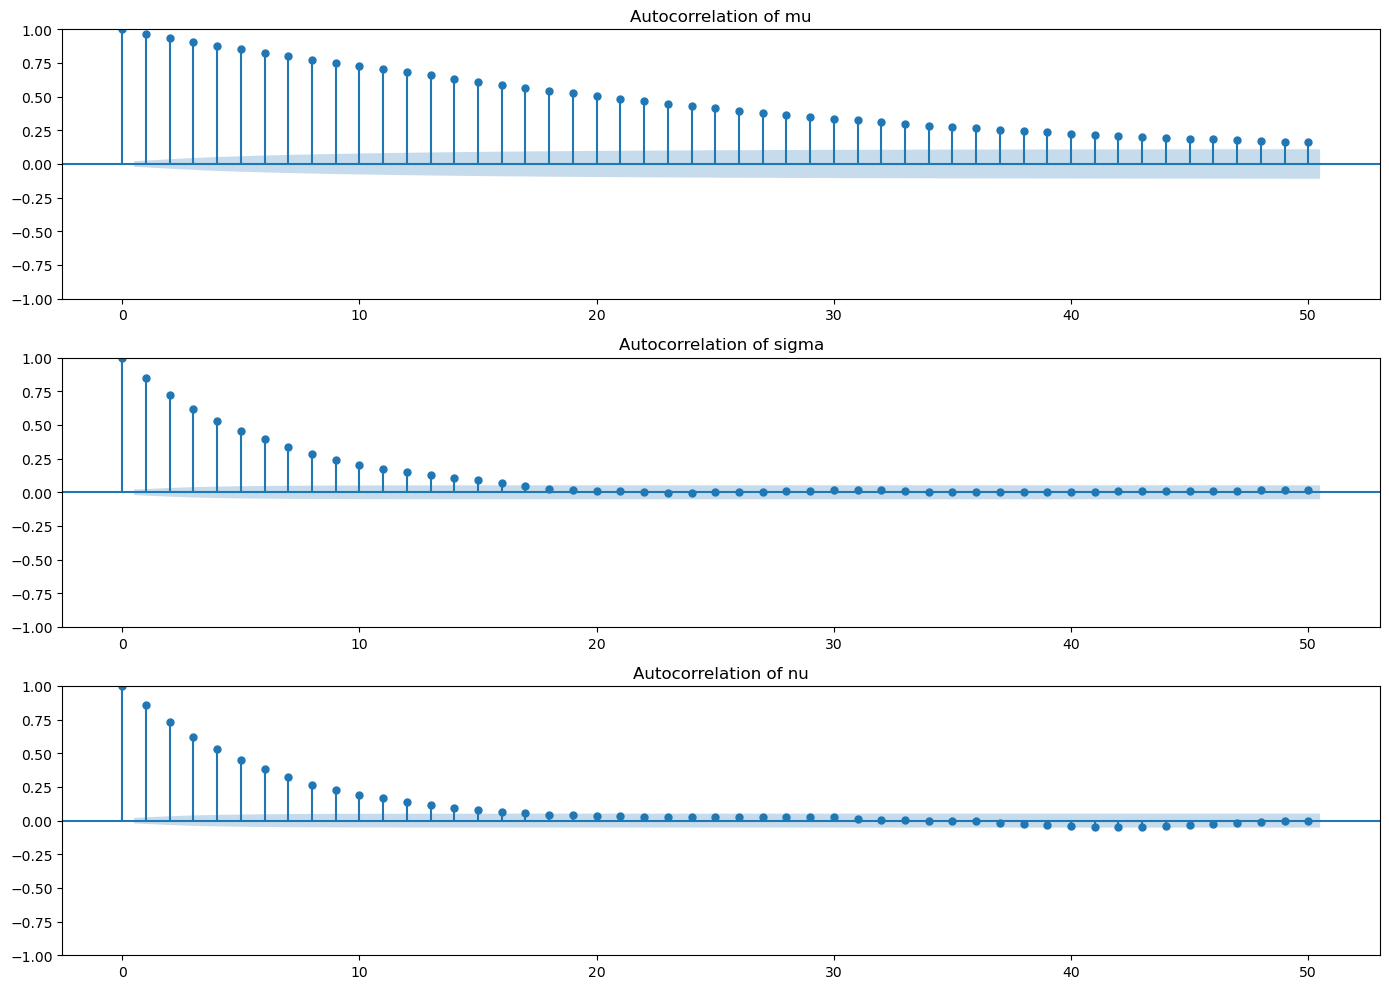

In [507]:
fig, axes = plt.subplots(3, 1, figsize=(14,10))

plot_acf(
    mu_chain_burned,
    lags=50,
    ax=axes[0]
)

axes[0].set_title("Autocorrelation of mu")

plot_acf(
    sigma_chain_burned,
    lags=50,
    ax=axes[1]
)

axes[1].set_title("Autocorrelation of sigma")

plot_acf(
    nu_chain_burned,
    lags=50,
    ax=axes[2]
)

axes[2].set_title("Autocorrelation of nu")

plt.tight_layout()

plt.show()

In [497]:
mu_bayes = np.mean(mu_chain_burned)
sigma_bayes = np.mean(sigma_chain_burned)
nu_bayes = np.mean(nu_chain_burned)

print(mu_bayes)
print(sigma_bayes)
print(nu_bayes)

0.0011976076993364582
0.019844676879545064
2.6545527225299614


In [498]:
bayesian_student_t = t.pdf(
    x,
    df=nu_bayes,
    loc=mu_bayes,
    scale=sigma_bayes
)

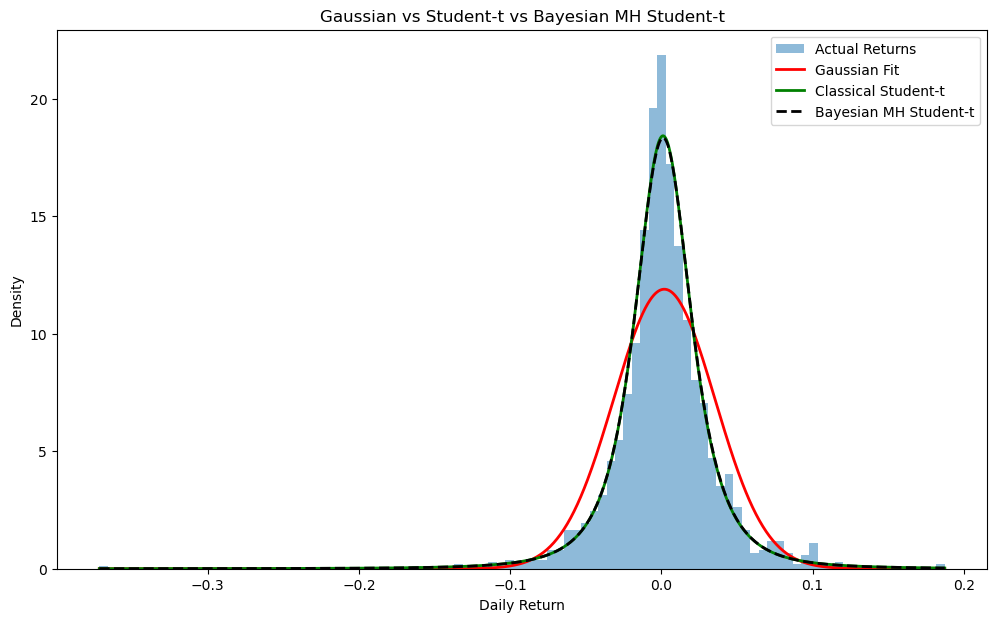

In [499]:
plt.figure(figsize=(12,7))

plt.hist(
    btc["Return"],
    bins=100,
    density=True,
    alpha=0.5,
    label="Actual Returns"
)

plt.plot(
    x,
    gaussian,
    color="red",
    linewidth=2,
    label="Gaussian Fit"
)

plt.plot(
    x,
    student_t,
    color="green",
    linewidth=2,
    label="Classical Student-t"
)

plt.plot(
    x,
    bayesian_student_t,
    color="black",
    linewidth=2,
    linestyle="--",
    label="Bayesian MH Student-t"
)

plt.xlabel("Daily Return")

plt.ylabel("Density")

plt.title("Gaussian vs Student-t vs Bayesian MH Student-t")

plt.legend()

plt.show()

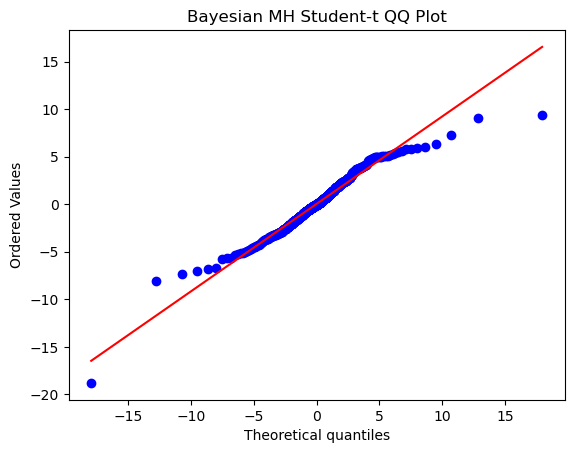

In [500]:
standardized_bayes = (

    (btc["Return"] - mu_bayes)

    / sigma_bayes
)

stats.probplot(

    standardized_bayes,

    dist=t,

    sparams=(nu_bayes,),

    plot=plt
)

plt.title("Bayesian MH Student-t QQ Plot")

plt.show()

In [501]:
log_likelihood_bayes = np.sum(

    t.logpdf(
        btc["Return"],
        df=nu_bayes,
        loc=mu_bayes,
        scale=sigma_bayes
    )
)

print(log_likelihood_bayes)

3828.5024685784747


In [502]:
gaussian_var_1 = norm.ppf(
    0.01,
    mu,
    sigma
)

print(gaussian_var_1)

-0.07606114209458231


In [503]:
student_t_var_classical = t.ppf(
    0.01,
    df=nu,
    loc=mu_t,
    scale=sigma_t
)

print(student_t_var_classical)

-0.10018677993349123


In [504]:
student_t_var_1 = t.ppf(
    0.01,
    df=nu_bayes,
    loc=mu_bayes,
    scale=sigma_bayes
)

print(student_t_var_1)

-0.09899261084257963
